In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import sys
import time

In [2]:
# Load the latest version
file_path = "./data/dataset.csv"

df = pd.read_csv(file_path)

print("First 5 records:\n", df.head())

First 5 records:
              Name     Nationality  Age Overall rating  \
0     J. Manzambi     Switzerland   19             77   
1       S. Baidoo         Austria   21             76   
2     14J. Putupu  American Samoa   37             39   
3  A. Al Khaibari    Saudi Arabia   28             70   
4       C. Varela        Portugal   16             68   

            Team & Contract      Height       Weight   foot Best position  \
0    SC Freiburg2024 ~ 2030  183cm 6'0"  75kg 165lbs  Right           CAM   
1        RC Lens2025 ~ 2030  190cm 6'3"  82kg 181lbs  Right            CB   
2        American SamoaFree  170cm 5'7"  73kg 161lbs  Right            CB   
3       Al Nassr2019 ~ 2029  175cm 5'9"  75kg 165lbs  Right           CDM   
4  Dinamo Zagreb2025 ~ 2028  169cm 5'7"  60kg 132lbs  Right            RM   

    Value  Total attacking  Total skill  Total movement  Total power  \
0  €22.5M              332          339             392          373   
1    €14M              220      

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12000 entries, 0 to 11999
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Name             12000 non-null  str  
 1   Nationality      12000 non-null  str  
 2   Age              12000 non-null  int64
 3   Overall rating   12000 non-null  str  
 4   Team & Contract  12000 non-null  str  
 5   Height           12000 non-null  str  
 6   Weight           12000 non-null  str  
 7   foot             12000 non-null  str  
 8   Best position    12000 non-null  str  
 9   Value            12000 non-null  str  
 10  Total attacking  12000 non-null  int64
 11  Total skill      12000 non-null  int64
 12  Total movement   12000 non-null  int64
 13  Total power      12000 non-null  int64
 14  Total mentality  12000 non-null  int64
 15  Total defending  12000 non-null  int64
 16  Body type        12000 non-null  str  
dtypes: int64(7), str(10)
memory usage: 1.6 MB


In [4]:
rows_before_gk_filter = len(df)

df = df.loc[
    df["Best position"].astype("string").str.strip().str.upper().ne("GK")
].copy()

print(f"Removed {rows_before_gk_filter - len(df):,} GK players.")
print(f"Remaining players: {len(df):,}")

Removed 1,251 GK players.
Remaining players: 10,749


In [5]:
import re

df = pd.read_csv(file_path)


def normalize_team(series):
    return (
        series.astype("string")
        .str.replace(r"(?:\d{4}.*|[A-Z][a-z]{2} \d{1,2}, \d{4}.*|Free)$", "", regex=True)
        .str.strip()
    )


def normalize_measure(series, unit):
    values = series.astype("string").str.extract(
        rf"(\d+(?:\.\d+)?)\s*{unit}", expand=False
    )
    return pd.to_numeric(values, errors="coerce").astype("Float64")


def normalize_value(series):
    values = series.astype("string").str.extract(
        r"€?\s*(\d+(?:\.\d+)?)\s*([KMB])?", expand=False
    )
    number = pd.to_numeric(values[0], errors="coerce")
    multiplier = values[1].map({"K": 0.001, "M": 1, "B": 1000}).fillna(1)
    return (number * multiplier).astype("Float64")


def normalize_body_type(series):
    return series.astype("string").str.replace(
        r"\s*\([^)]*\)", "", regex=True
    ).str.strip()


# Keep only the requested unit or text portion in each field.
df["Team & Contract"] = normalize_team(df["Team & Contract"])
df["Height"] = normalize_measure(df["Height"], "cm")
df["Weight"] = normalize_measure(df["Weight"], "kg")
df["Value"] = normalize_value(df["Value"])
df["Body type"] = normalize_body_type(df["Body type"])

rows_before_filter = len(df)
df = df.loc[df["Value"].gt(0)].copy()

output_path = "./data/dataset_cleaned.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(
    f"Removed {rows_before_filter - len(df):,} rows with Value == 0. "
    f"Saved {len(df):,} rows to {output_path}"
)
df[["Team & Contract", "Height", "Weight", "Value", "Body type"]].head()

Removed 190 rows with Value == 0. Saved 11,810 rows to ./data/dataset_cleaned.csv


,Team & Contract,Height,Weight,Value,Body type
0,SC Freiburg,183.0,75.0,22.5,Normal
1,RC Lens,190.0,82.0,14.0,Normal
3,Al Nassr,175.0,75.0,1.4,Lean
4,Dinamo Zagreb,169.0,60.0,3.3,Lean
5,Real Madrid,186.0,75.0,150.5,Normal


In [6]:
# Add a unique row identifier and classify every column.
if "ID" in df.columns:
    df = df.drop(columns="ID")
df.insert(0, "ID", range(1, len(df) + 1))

numeric_columns = [
    "Age",
    "Overall rating",
    "Height",
    "Weight",
    "Value",
    "Total attacking",
    "Total skill",
    "Total movement",
    "Total power",
    "Total mentality",
    "Total defending",
]
categorical_columns = [
    "Name",
    "Nationality",
    "Team & Contract",
    "foot",
    "Best position",
    "Body type",
]

column_types = pd.DataFrame({"Column": df.columns})
column_types["Type"] = column_types["Column"].map(
    lambda column: "Key" if column == "ID"
    else "Numeric" if column in numeric_columns
    else "Categorical" if column in categorical_columns
    else "Unknown"
)

if column_types["Type"].eq("Unknown").any():
    raise ValueError(
        f"Unclassified columns: {column_types.loc[column_types['Type'].eq('Unknown'), 'Column'].tolist()}"
    )

output_path = "./data/dataset_cleaned.csv"
df.to_csv(output_path, index=False, encoding="utf-8-sig")

print(f"Added unique ID for {len(df):,} rows")
print(f"Saved classified dataset to {output_path}")
column_types

Added unique ID for 11,810 rows
Saved classified dataset to ./data/dataset_cleaned.csv


,Column,Type
0,ID,Key
1,Name,Categorical
2,Nationality,Categorical
3,Age,Numeric
4,Overall rating,Numeric
5,Team & Contract,Categorical
6,Height,Numeric
7,Weight,Numeric
8,foot,Categorical
9,Best position,Categorical


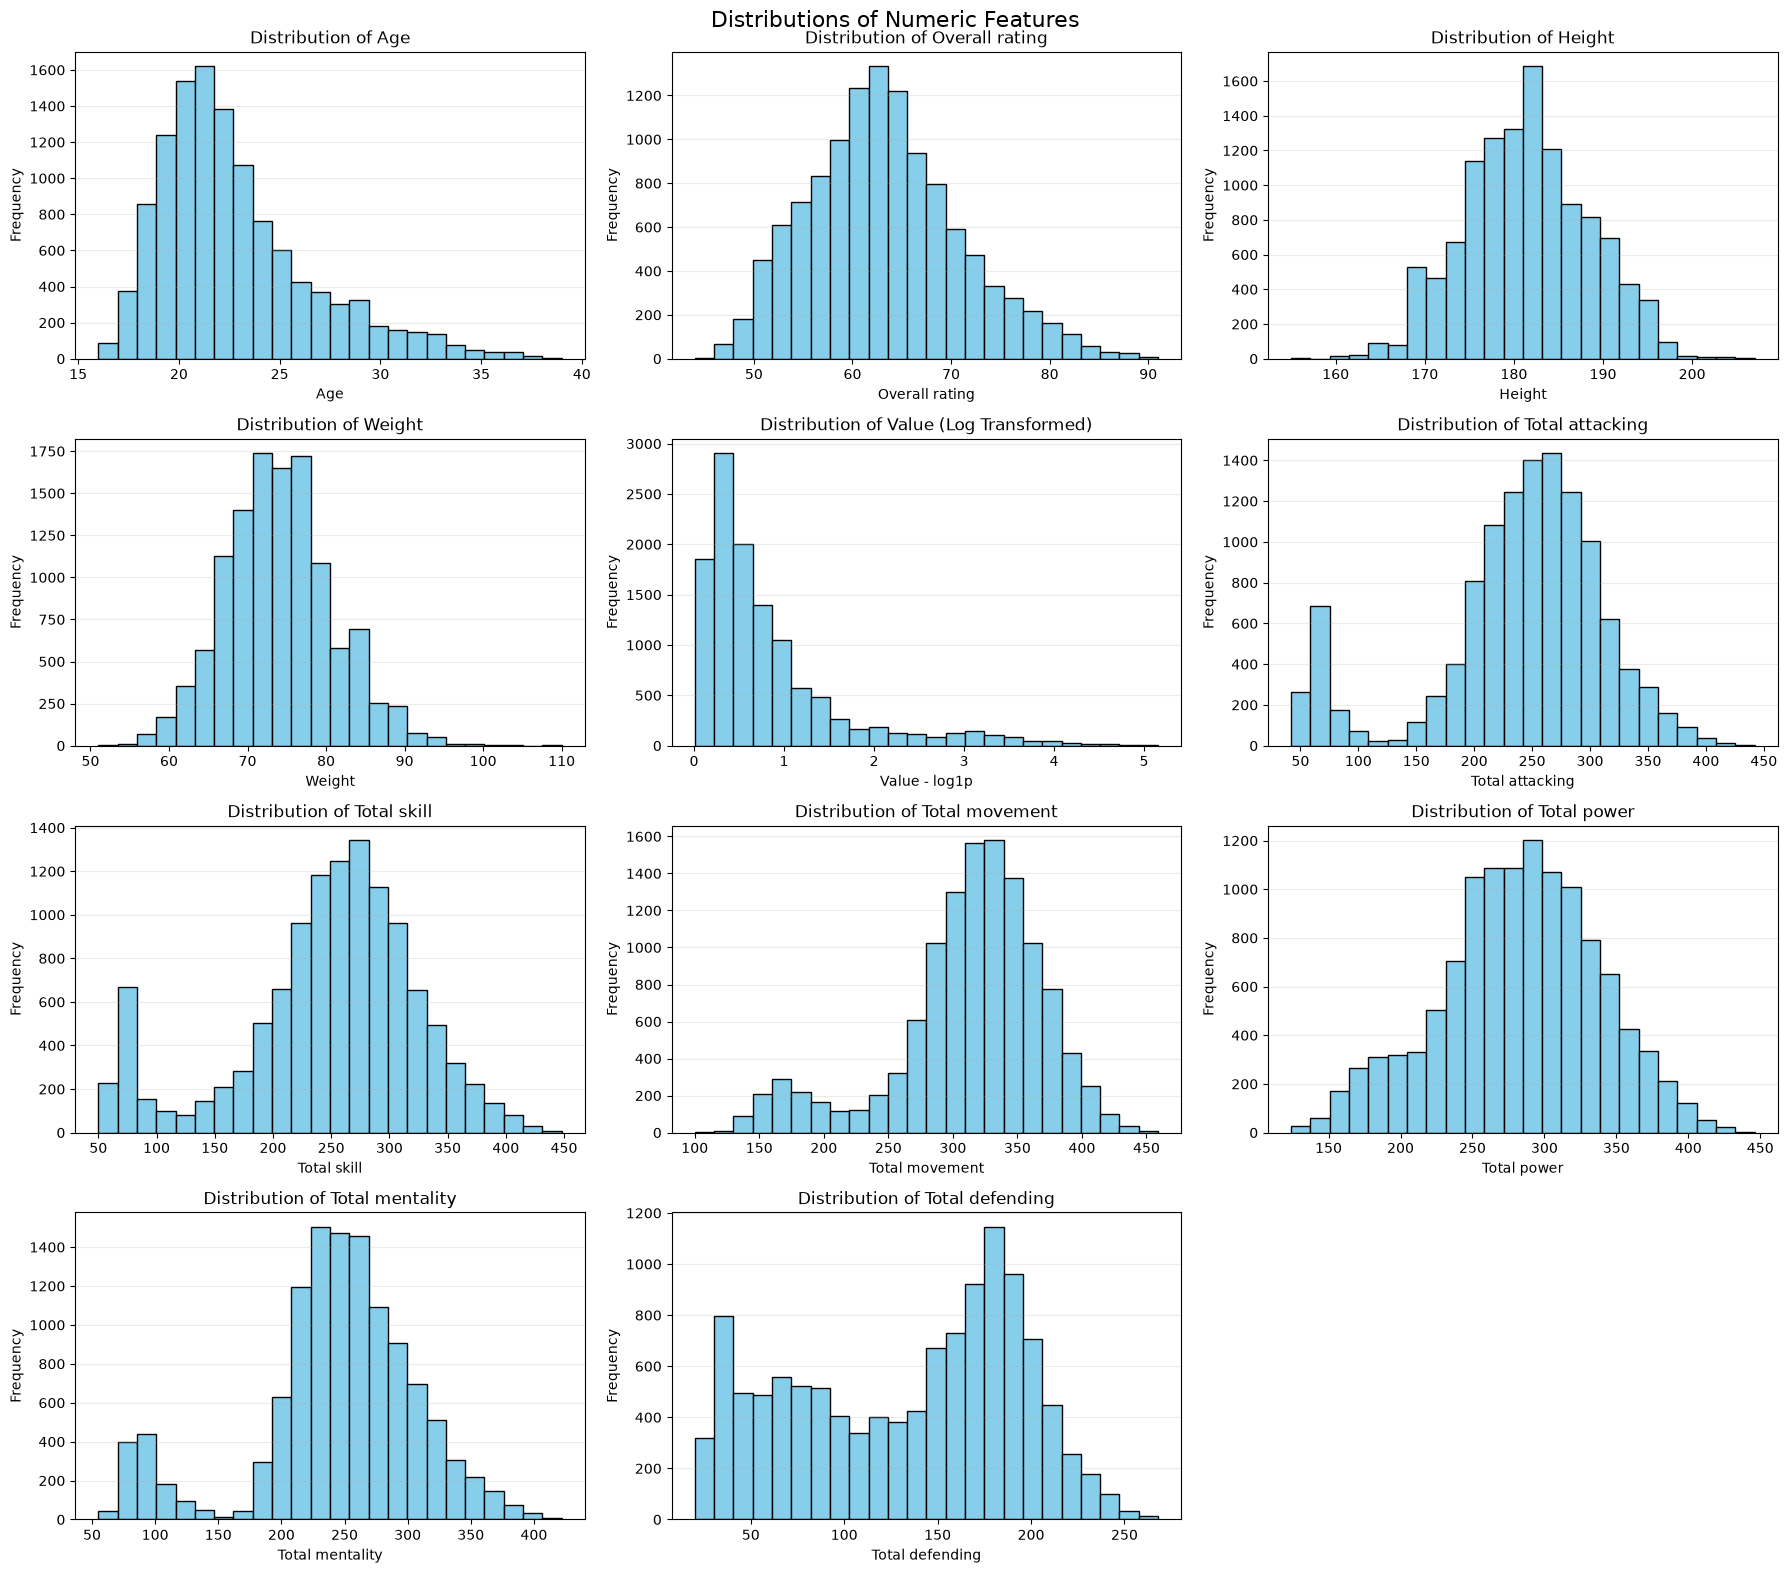

In [7]:
# Plot numeric distributions, using log transformation for skewed features.
numeric_data = df[numeric_columns].apply(pd.to_numeric, errors="coerce")
log_transformed_columns = {"Value"}
numeric_data[list(log_transformed_columns)] = np.log1p(
    numeric_data[list(log_transformed_columns)]
)

number_of_columns = 3
number_of_rows = int(np.ceil(len(numeric_columns) / number_of_columns))
fig, axes = plt.subplots(
    number_of_rows,
    number_of_columns,
    figsize=(18, 4 * number_of_rows),
)
axes = np.asarray(axes).reshape(-1)

for axis, column in zip(axes, numeric_columns):
    axis.hist(
        numeric_data[column].dropna(),
        bins=24,
        color="skyblue",
        edgecolor="black",
    )
    axis_title = f"Distribution of {column}"
    axis_label = column
    if column in log_transformed_columns:
        axis_title += " (Log Transformed)"
        axis_label += " - log1p"
    axis.set_title(axis_title)
    axis.set_xlabel(axis_label)
    axis.set_ylabel("Frequency")
    axis.grid(axis="y", alpha=0.25)

for axis in axes[len(numeric_columns):]:
    axis.set_visible(False)

fig.suptitle("Distributions of Numeric Features", fontsize=16)
fig.tight_layout()
plt.show()

In [8]:
# Create a separate CSV with prefixed categorical values and tokenized numeric values.
categorical_prefixes = {
    "Nationality": "Na",
    "Team & Contract": "Tc",
    "foot": "F",
    "Best position": "Bp",
    "Body type": "Bt",
}
numeric_prefixes = {
    "Age": "a",
    "Overall rating": "o",
    "Height": "h",
    "Weight": "w",
    "Value": "v",
    "Total attacking": "ta",
    "Total skill": "ts",
    "Total movement": "tm",
    "Total power": "tp",
    "Total mentality": "tme",
    "Total defending": "td",
}

tokenized_df = df[["ID", *categorical_columns]].copy()

for column, prefix in categorical_prefixes.items():
    tokenized_df[column] = (
        tokenized_df[column]
        .astype("string")
        .map(lambda value: f"{prefix}_{value}" if pd.notna(value) else "NA")
    )

for column, prefix in numeric_prefixes.items():
    values = pd.to_numeric(df[column], errors="coerce")
    bin_numbers = pd.qcut(
        values,
        q=5,
        labels=False,
        duplicates="drop",
    )
    tokenized_df[column] = (
        bin_numbers.add(1)
        .astype("Int64")
        .astype("string")
        .radd(prefix)
        .fillna("NA")
    )

tokenized_output_path = "./data/dataset_tokenized.csv"
tokenized_df.to_csv(
    tokenized_output_path,
    index=False,
    encoding="utf-8-sig",
)

print(f"Saved {len(tokenized_df):,} tokenized rows to {tokenized_output_path}")
tokenized_df.head()

Saved 11,810 tokenized rows to ./data/dataset_tokenized.csv


,ID,Name,Nationality,Team & Contract,foot,Best position,Body type,Age,Overall rating,Height,Weight,Value,Total attacking,Total skill,Total movement,Total power,Total mentality,Total defending
0,1,J. Manzambi,Na_Switzerland,Tc_SC Freiburg,F_Right,Bp_CAM,Bt_Normal,a1,o5,h3,w3,v5,ta5,ts5,tm5,tp5,tme5,td5
1,2,S. Baidoo,Na_Austria,Tc_RC Lens,F_Right,Bp_CB,Bt_Normal,a2,o5,h5,w5,v5,ta2,ts3,tm3,tp3,tme4,td5
3,3,A. Al Khaibari,Na_Saudi Arabia,Tc_Al Nassr,F_Right,Bp_CDM,Bt_Lean,a5,o5,h1,w3,v4,ta3,ts4,tm4,tp4,tme4,td5
4,4,C. Varela,Na_Portugal,Tc_Dinamo Zagreb,F_Right,Bp_RM,Bt_Lean,a1,o4,h1,w1,v5,ta4,ts5,tm4,tp3,tme3,td1
5,5,J. Bellingham,Na_England,Tc_Real Madrid,F_Right,Bp_CAM,Bt_Normal,a3,o5,h4,w3,v5,ta5,ts5,tm5,tp5,tme5,td5


In [9]:
# Create a bag of tokens for each player.
# ID and Name are kept as identifiers but excluded from training.

training_columns = [
    "Nationality",
    "Team & Contract",
    "foot",
    "Best position",
    "Body type",
    "Age",
    "Overall rating",
    "Height",
    "Weight",
    "Value",
    "Total attacking",
    "Total skill",
    "Total movement",
    "Total power",
    "Total mentality",
    "Total defending",
]

player_bags = tokenized_df[training_columns].apply(
    lambda row: list(row.dropna()),
    axis=1,
)

print(player_bags.iloc[0])

['Na_Switzerland', 'Tc_SC Freiburg', 'F_Right', 'Bp_CAM', 'Bt_Normal', 'a1', 'o5', 'h3', 'w3', 'v5', 'ta5', 'ts5', 'tm5', 'tp5', 'tme5', 'td5']


In [10]:
from collections import Counter

token_counter = Counter()

for bag in player_bags:
    token_counter.update(bag)

vocabulary = sorted(token_counter.keys())

token_to_id = {
    token: index
    for index, token in enumerate(vocabulary)
}

id_to_token = {
    index: token
    for token, index in token_to_id.items()
}

print(f"Vocabulary size: {len(vocabulary):,}")

Vocabulary size: 1,189


In [11]:
for token, token_id in list(token_to_id.items())[:20]:
    print(f"{token:<30} → {token_id}")

Bp_CAM                         → 0
Bp_CB                          → 1
Bp_CDM                         → 2
Bp_CF                          → 3
Bp_CM                          → 4
Bp_GK                          → 5
Bp_LB                          → 6
Bp_LM                          → 7
Bp_LW                          → 8
Bp_LWB                         → 9
Bp_RB                          → 10
Bp_RM                          → 11
Bp_RW                          → 12
Bp_RWB                         → 13
Bp_ST                          → 14
Bt_Lean                        → 15
Bt_Normal                      → 16
Bt_Stocky                      → 17
Bt_Unique                      → 18
F_Left                         → 19


In [12]:
encoded_player_bags = player_bags.apply(
    lambda bag: [
        token_to_id[token]
        for token in bag
    ]
)

print(encoded_player_bags.iloc[0])

[167, 905, 20, 0, 16, 1134, 1148, 1141, 1186, 1183, 1153, 1178, 1163, 1173, 1168, 1158]


In [13]:
def create_training_samples(encoded_bags):
    contexts = []
    targets = []

    for bag in encoded_bags:

        for target_index in range(len(bag)):

            target = bag[target_index]

            context = [
                token_id
                for index, token_id in enumerate(bag)
                if index != target_index
            ]

            contexts.append(context)
            targets.append(target)

    return contexts, targets


contexts, targets = create_training_samples(
    encoded_player_bags
)

print("Number of training samples:", len(contexts))
print()
print("Context:")
print(contexts[0])
print()
print("Target:")
print(targets[0])

Number of training samples: 188960

Context:
[905, 20, 0, 16, 1134, 1148, 1141, 1186, 1183, 1153, 1178, 1163, 1173, 1168, 1158]

Target:
167


In [14]:
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics.pairwise import cosine_similarity

# Train a CBOW model: the remaining row tokens predict the target token.
torch.manual_seed(42)

context_tensor = torch.tensor(contexts, dtype=torch.long)
target_tensor = torch.tensor(targets, dtype=torch.long)
training_loader = DataLoader(
    TensorDataset(context_tensor, target_tensor),
    batch_size=512,
    shuffle=True,
)

class CBOWModel(nn.Module):
    def __init__(self, vocabulary_size, embedding_dimension=64):
        super().__init__()
        self.embedding = nn.Embedding(vocabulary_size, embedding_dimension)
        self.output = nn.Linear(embedding_dimension, vocabulary_size)

    def forward(self, context_tokens):
        context_embedding = self.embedding(context_tokens).mean(dim=1)
        return self.output(context_embedding)


model = CBOWModel(len(vocabulary))
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
loss_function = nn.CrossEntropyLoss()

loss_history = []
for epoch in range(20):
    total_loss = 0.0
    for context_batch, target_batch in training_loader:
        optimizer.zero_grad()
        predictions = model(context_batch)
        loss = loss_function(predictions, target_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(target_batch)

    epoch_loss = total_loss / len(target_tensor)
    loss_history.append(epoch_loss)
    print(f"Epoch {epoch + 1:02d}/20 - loss: {epoch_loss:.4f}")

# Represent each player by the mean of its learned token embeddings.
with torch.no_grad():
    token_embeddings = model.embedding.weight
    player_embeddings = torch.stack([
        token_embeddings[torch.tensor(bag)].mean(dim=0)
        for bag in encoded_player_bags
    ]).numpy()


def find_similar_players(player_id, top_n=10):
    matching_rows = df.index[df["ID"].eq(player_id)].tolist()
    if not matching_rows:
        raise ValueError(f"Player ID {player_id} was not found.")

    player_index = matching_rows[0]
    similarity_scores = cosine_similarity(
        player_embeddings[player_index:player_index + 1],
        player_embeddings,
    ).ravel()
    similar_indices = similarity_scores.argsort()[::-1]
    similar_indices = [
        index for index in similar_indices if index != player_index
    ][:top_n]

    # Return the complete non-tokenized player records with the similarity score.
    result = df.iloc[similar_indices].copy()
    result.insert(1, "Similarity", similarity_scores[similar_indices])
    return result.reset_index(drop=True)


query_id = int(df.iloc[0]["ID"])
print(f"Similar players for ID {query_id}:")
find_similar_players(query_id, top_n=10)

Epoch 01/20 - loss: 3.1550
Epoch 02/20 - loss: 1.4840
Epoch 03/20 - loss: 1.2688
Epoch 04/20 - loss: 1.1441
Epoch 05/20 - loss: 1.0597
Epoch 06/20 - loss: 0.9999
Epoch 07/20 - loss: 0.9580
Epoch 08/20 - loss: 0.9272
Epoch 09/20 - loss: 0.9030
Epoch 10/20 - loss: 0.8834
Epoch 11/20 - loss: 0.8662
Epoch 12/20 - loss: 0.8526
Epoch 13/20 - loss: 0.8400
Epoch 14/20 - loss: 0.8296
Epoch 15/20 - loss: 0.8192
Epoch 16/20 - loss: 0.8110
Epoch 17/20 - loss: 0.8024
Epoch 18/20 - loss: 0.7956
Epoch 19/20 - loss: 0.7886
Epoch 20/20 - loss: 0.7826
Similar players for ID 1:


,ID,Similarity,Name,Nationality,Age,Overall rating,Team & Contract,Height,Weight,foot,Best position,Value,Total attacking,Total skill,Total movement,Total power,Total mentality,Total defending,Body type
0,7721,0.770885,U. Bislimi,Switzerland,25,72,FC Lugano,183.0,78.0,Right,CAM,3.1,324,354,352,347,336,192,Normal
1,259,0.707526,Alvyn Sanches,Switzerland,22,73,BSC Young Boys,183.0,68.0,Left,LM,7.0,300,326,403,329,325,193,Lean
2,147,0.696984,D. Ndoye,Switzerland,24,77,Nottingham Forest,184.0,79.0,Right,RM,14.5,341,353,410,353,326,191,Normal
3,1183,0.675660,Hannibal,Tunisia,22,75,Burnley,182.0,70.0,Right,CM,11.5,328,371,380,376,363,212,Lean
4,276,0.663432,Gustavo Sá,Portugal,20,75,Famalicão,189.0,83.0,Right,CAM,12.5,350,366,372,369,367,211,Normal
5,173,0.662924,A. Tóth,Hungary,19,72,AFC Bournemouth,181.0,70.0,Right,CAM,5.5,327,371,334,331,330,204,Lean
6,702,0.662924,A. Tóth,Hungary,19,72,AFC Bournemouth,181.0,70.0,Right,CAM,5.5,327,371,334,331,330,204,Lean
7,2692,0.642309,N. Aséko,Germany,19,70,Hannover 96,178.0,73.0,Right,CM,3.8,271,308,362,322,321,204,Normal
8,1523,0.637927,F. Ugrinić,Switzerland,26,75,Valencia CF,184.0,88.0,Right,CM,6.5,350,367,381,416,356,210,Stocky
9,536,0.637927,F. Ugrinić,Switzerland,26,75,Valencia CF,184.0,88.0,Right,CM,6.5,350,367,381,416,356,210,Stocky


In [15]:
import json
import sqlite3

# Store player embeddings in SQLite for SQL-based similarity queries.
database_path = "./data/player_embeddings.db"
connection = sqlite3.connect(database_path)
connection.execute("DROP TABLE IF EXISTS player_embeddings")
connection.execute(
    """
    CREATE TABLE player_embeddings (
        id INTEGER PRIMARY KEY,
        name TEXT NOT NULL,
        nationality TEXT,
        best_position TEXT,
        embedding TEXT NOT NULL
    )
    """
)

embedding_rows = [
    (
        int(player_id),
        str(name),
        str(nationality),
        str(best_position),
        json.dumps(embedding.tolist()),
    )
    for player_id, name, nationality, best_position, embedding in zip(
        df["ID"],
        df["Name"],
        df["Nationality"],
        df["Best position"],
        player_embeddings,
    )
]
connection.executemany(
    """
    INSERT INTO player_embeddings
        (id, name, nationality, best_position, embedding)
    VALUES (?, ?, ?, ?, ?) 
    """,
    embedding_rows,
)
connection.commit()


def cosine_from_json(left_json, right_json):
    left = np.asarray(json.loads(left_json), dtype=float)
    right = np.asarray(json.loads(right_json), dtype=float)
    denominator = np.linalg.norm(left) * np.linalg.norm(right)
    return float(np.dot(left, right) / denominator) if denominator else 0.0


connection.create_function("cosine_similarity", 2, cosine_from_json)
query_id = int(df.iloc[0]["ID"])
target_embedding = json.dumps(player_embeddings[0].tolist())
similarity_result = pd.read_sql_query(
    """
    SELECT id AS ID,
           cosine_similarity(embedding, ?) AS Similarity
    FROM player_embeddings
    WHERE id <> ?
    ORDER BY Similarity DESC
    LIMIT 10
    """,
    connection,
    params=(target_embedding, query_id),
)

# Join SQL similarity scores to complete non-tokenized player records.
query_result = similarity_result.merge(df, on="ID", how="left")
query_result = query_result[["ID", "Similarity", *[
    column for column in df.columns if column != "ID"
]]]

print(f"Saved {len(embedding_rows):,} embeddings to {database_path}")
query_result

Saved 11,810 embeddings to ./data/player_embeddings.db


,ID,Similarity,Name,Nationality,Age,Overall rating,Team & Contract,Height,Weight,foot,Best position,Value,Total attacking,Total skill,Total movement,Total power,Total mentality,Total defending,Body type
0,7721,0.770885,U. Bislimi,Switzerland,25,72,FC Lugano,183.0,78.0,Right,CAM,3.1,324,354,352,347,336,192,Normal
1,259,0.707526,Alvyn Sanches,Switzerland,22,73,BSC Young Boys,183.0,68.0,Left,LM,7.0,300,326,403,329,325,193,Lean
2,147,0.696984,D. Ndoye,Switzerland,24,77,Nottingham Forest,184.0,79.0,Right,RM,14.5,341,353,410,353,326,191,Normal
3,1183,0.675660,Hannibal,Tunisia,22,75,Burnley,182.0,70.0,Right,CM,11.5,328,371,380,376,363,212,Lean
4,276,0.663432,Gustavo Sá,Portugal,20,75,Famalicão,189.0,83.0,Right,CAM,12.5,350,366,372,369,367,211,Normal
5,173,0.662924,A. Tóth,Hungary,19,72,AFC Bournemouth,181.0,70.0,Right,CAM,5.5,327,371,334,331,330,204,Lean
6,702,0.662924,A. Tóth,Hungary,19,72,AFC Bournemouth,181.0,70.0,Right,CAM,5.5,327,371,334,331,330,204,Lean
7,2692,0.642309,N. Aséko,Germany,19,70,Hannover 96,178.0,73.0,Right,CM,3.8,271,308,362,322,321,204,Normal
8,536,0.637927,F. Ugrinić,Switzerland,26,75,Valencia CF,184.0,88.0,Right,CM,6.5,350,367,381,416,356,210,Stocky
9,1523,0.637927,F. Ugrinić,Switzerland,26,75,Valencia CF,184.0,88.0,Right,CM,6.5,350,367,381,416,356,210,Stocky


In [16]:
query_id = 17
player_info = df.loc[df["ID"] == query_id]

if player_info.empty:
    print(f"Không tìm thấy cầu thủ có ID = {query_id}")
else:
    display(player_info)
find_similar_players(query_id, top_n=10)

,ID,Name,Nationality,Age,Overall rating,Team & Contract,Height,Weight,foot,Best position,Value,Total attacking,Total skill,Total movement,Total power,Total mentality,Total defending,Body type
18,17,K. Mbappé,France,26,91,Real Madrid,182.0,81.0,Right,ST,157.0,424,408,459,427,357,92,Unique


,ID,Similarity,Name,Nationality,Age,Overall rating,Team & Contract,Height,Weight,foot,Best position,Value,Total attacking,Total skill,Total movement,Total power,Total mentality,Total defending,Body type
0,1569,0.720787,R. Hack,Germany,26,77,Borussia Mönchengladbach,178.0,72.0,Right,LM,11.5,343,374,401,358,271,93,Lean
1,588,0.717214,S. Gnabry,Germany,29,83,FC Bayern München,176.0,77.0,Right,CAM,35.5,370,378,414,366,329,132,Unique
2,192,0.713801,E. Can,Germany,31,82,Borussia Dortmund,186.0,86.0,Right,CB,21.0,362,363,353,401,394,250,Stocky
3,1917,0.712306,K. Karaman,Türkiye,31,73,FC Schalke,189.0,84.0,Right,CAM,2.5,353,313,359,377,304,66,Lean
4,68,0.681571,S. El Mala,Germany,18,76,1. FC Köln,187.0,80.0,Right,CAM,16.0,313,342,414,356,291,117,Normal
5,1279,0.681259,O. Traoré,Germany,27,72,1. FC Heidenheim,187.0,78.0,Right,RB,2.3,261,294,378,354,313,208,Lean
6,1918,0.671697,R. Andrich,Germany,30,79,Bayer 04 Leverkusen,186.0,85.0,Right,CB,14.5,368,384,314,401,374,238,Normal
7,14,0.670227,K. Adeyemi,Germany,23,82,Borussia Dortmund,180.0,77.0,Left,ST,43.5,374,364,441,399,316,108,Lean
8,1743,0.666791,M. Wanitzek,Germany,32,75,Karlsruher SC,179.0,74.0,Right,CM,4.4,348,375,369,374,352,184,Lean
9,497,0.664297,J. Leweling,Germany,24,78,VfB Stuttgart,185.0,86.0,Right,RM,19.0,344,322,402,389,302,126,Normal


In [ ]:
def calculate_evaluation_score(query_id, similar_df):
    # Lấy thông tin cầu thủ query từ dataframe gốc
    query_row = df.loc[df['ID'] == query_id].iloc[0]
    
    cat_features = ["Nationality", "Team & Contract", "foot", "Best position", "Body type"]
    num_features = [
        "Age", "Overall rating", "Height", "Weight", "Value", 
        "Total attacking", "Total skill", "Total movement", 
        "Total power", "Total mentality", "Total defending"
    ]
    
    scores = []
    for _, candidate_row in similar_df.iterrows():
        S = 0.0
        
        # 1. Tính điểm cho Categorical features
        for col in cat_features:
            if str(query_row[col]) == str(candidate_row[col]):
                S += 1.0
                
        # 2. Tính điểm cho Numeric features
        for col in num_features:
            try:
                q_val = float(query_row[col])
                c_val = float(candidate_row[col])
                
                # Xử lý trường hợp cả 2 đều bằng 0
                if q_val == 0 and c_val == 0:
                    S += 1.0
                elif max(q_val, c_val) != 0:
                    S += min(q_val, c_val) / max(q_val, c_val)
            except (ValueError, TypeError):
                pass # Bỏ qua nếu dữ liệu lỗi
        scores.append(S)
        
    # Tạo bản sao của dataframe kết quả để thêm cột điểm
    result_df = similar_df.copy()
    
    # Số lượng features
    total_features = len(cat_features) + len(num_features)
    
    
    # Chèn thêm cột Độ chính xác (%)
    result_df.insert(4, 'Accuracy (%)', (result_df['Eval Score (S)'] / total_features * 100).round(2))
    
    return result_df

# Thử nghiệm hàm đánh giá với query_id = 17
query_id = 17
similar_players = find_similar_players(query_id, top_n=10)
evaluated_results = calculate_evaluation_score(query_id, similar_players)

print(f"Kết quả đánh giá độ tương đồng cho cầu thủ ID {query_id}:")
display(evaluated_results)

KeyError: 'Eval Score (S)'

In [ ]:
from collections import Counter
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt

def evaluate_bins_impact(bin_list, sample_size=50, top_n=10):
    sim_scores = []
    acc_scores = []
    
    # Lấy mẫu ngẫu nhiên một số ID để đánh giá (chọn ngẫu nhiên hoặc lấy head, ở đây mình lấy 50 người đầu)
    sample_query_ids = df["ID"].head(sample_size).tolist()
    
    cat_features = ["Nationality", "Team & Contract", "foot", "Best position", "Body type"]
    num_features = [
        "Age", "Overall rating", "Height", "Weight", "Value", 
        "Total attacking", "Total skill", "Total movement", 
        "Total power", "Total mentality", "Total defending"
    ]
    total_features = len(cat_features) + len(num_features)
    
    for q_bins in bin_list:
        # 1. Token hóa với số bins = q_bins
        tokenized_temp = df[["ID", *categorical_columns]].copy()
        for column, prefix in categorical_prefixes.items():
            tokenized_temp[column] = tokenized_temp[column].astype("string").map(lambda value: f"{prefix}_{value}" if pd.notna(value) else "NA")
            
        for column, prefix in numeric_prefixes.items():
            values = pd.to_numeric(df[column], errors="coerce")
            bin_numbers = pd.qcut(values, q=q_bins, labels=False, duplicates="drop")
            tokenized_temp[column] = bin_numbers.add(1).astype("Int64").astype("string").radd(prefix).fillna("NA")
            
        # 2. Tạo tập Bag of Tokens
        player_bags_temp = tokenized_temp[training_columns].apply(lambda row: list(row.dropna()), axis=1)
        
        # 3. Tạo BoW Matrix
        temp_counter = Counter()
        for bag in player_bags_temp:
            temp_counter.update(bag)
        temp_vocab = sorted(temp_counter.keys())
        temp_token_to_id = {token: index for index, token in enumerate(temp_vocab)}
        
        encoded_bags = player_bags_temp.apply(lambda bag: [temp_token_to_id[token] for token in bag])
        
        bow_matrix = np.zeros((len(encoded_bags), len(temp_vocab)), dtype=np.float32)
        for i, bag in enumerate(encoded_bags):
            for token_id in bag:
                bow_matrix[i, token_id] += 1.0
                
        # 4. Truy vấn & Đánh giá
        avg_sim = []
        avg_acc = []
        
        for query_id in sample_query_ids:
            matching_rows = df.index[df["ID"].eq(query_id)].tolist()
            if not matching_rows: continue
            player_index = matching_rows[0]
            
            similarity_scores = cosine_similarity(
                bow_matrix[player_index:player_index + 1],
                bow_matrix,
            ).ravel()
            
            similar_indices = similarity_scores.argsort()[::-1]
            similar_indices = [idx for idx in similar_indices if idx != player_index][:top_n]
            
            # Ghi nhận trung bình Cosine Similarity của top N
            avg_sim.append(np.mean(similarity_scores[similar_indices]))
            
            # Ghi nhận Accuracy metric của top N
            query_row = df.iloc[player_index]
            query_accs = []
            for candidate_idx in similar_indices:
                candidate_row = df.iloc[candidate_idx]
                S = 0.0
                for col in cat_features:
                    if str(query_row[col]) == str(candidate_row[col]): S += 1.0
                for col in num_features:
                    try:
                        q_val = float(query_row[col])
                        c_val = float(candidate_row[col])
                        if q_val == 0 and c_val == 0: S += 1.0
                        elif max(q_val, c_val) != 0: S += min(q_val, c_val) / max(q_val, c_val)
                    except: pass
                query_accs.append(S / total_features)
            avg_acc.append(np.mean(query_accs))
            
        sim_scores.append(np.mean(avg_sim))
        acc_scores.append(np.mean(avg_acc))
        print(f"Bins: {q_bins:2d} | Similarity trung bình: {sim_scores[-1]:.4f} | Accuracy trung bình: {acc_scores[-1]:.4f}")
        
    # 5. Vẽ biểu đồ
    plt.figure(figsize=(10, 6))
    plt.plot(bin_list, sim_scores, marker='o', linewidth=2, label='Cosine Similarity (Model)')
    plt.plot(bin_list, acc_scores, marker='s', linewidth=2, label='Accuracy (Custom Metric)')
    plt.xlabel('Số lượng Bins (q_bins)')
    plt.ylabel('Score (0 - 1)')
    plt.title('Sự thay đổi của Similarity và Accuracy khi thay đổi số lượng Bins', fontsize=14)
    plt.xticks(bin_list)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Chạy thử nghiệm đánh giá tác động của số lượng bins (ví dụ: từ 2 đến 30)
bin_counts = [2, 3, 5, 8, 10, 15, 20, 30]
evaluate_bins_impact(bin_counts, sample_size=50, top_n=10)
